In [16]:
import pickle
import igraph

with open("graphs/real/FINDER/Digg.pkl",'rb') as f:
    g = pickle.load(f) 

print(g.summary())

IGRAPH U--- 29652 84781 -- 
+ attr: _nx_name (v)


create a baseline of multi layer network dismantling,take the graph load from Digg.pkl

for each layer:
    - node clustering into K communities
    - using degree heuristics to find the most important node in each community
    - remove the K best nodes

In [11]:
'''Community Detection Methods'''

def FastGreedy(g:ig.Graph, K:int):
    '''
    Fast greedy community detection
    Returns membership list where membership[i] is the community of node i
    '''
    try:
        communities = g.community_fastgreedy()
        membership = communities.as_clustering(n=min(K, g.vcount())).membership
    except:
        # Fallback to label propagation if fastgreedy fails
        membership = g.community_label_propagation().membership
    return membership


def LabelPropagation(g:ig.Graph, K:int):
    '''
    Label propagation community detection
    Returns membership list where membership[i] is the community of node i
    Note: K is not directly used as label propagation determines communities automatically
    '''
    membership = g.community_label_propagation().membership
    return membership


def Louvain(g:ig.Graph, K:int):
    '''
    Louvain (multilevel) community detection
    Returns membership list where membership[i] is the community of node i
    Note: K is not directly used as Louvain determines communities automatically
    '''
    membership = g.community_multilevel().membership
    return membership


def community_detection(g:ig.Graph, K:int, community_method=None):
    '''
    Generic community detection wrapper
    
    Args:
        g: igraph Graph object
        K: target number of communities
        community_method: function that takes (g, K) and returns membership list
                         If None, defaults to FastGreedy
    
    Returns:
        membership: list where membership[i] is the community node i belongs to
    '''
    if community_method is None:
        community_method = FastGreedy
    
    return community_method(g, K)

centratity bases methods
- Degree
- Betweenness
- Pagerank
- CI

In [ ]:
'''centrality '''
from copy import deepcopy
import igraph as ig

def Degree(g:ig.Graph,k:int):
    '''
    return the nodes with top-k highest degree in a graph
    '''
    # handle invalid 
    if k==0: k = 1
    k = int(k)  # ensure k is integer
    
    # get all nodes and their degrees
    degrees = [(node, g.degree(node)) for node in range(g.vcount())]
    
    # sort by degree in descending order and get top k
    degrees.sort(key=lambda x: x[1], reverse=True)
    
    # return the node indices of top k nodes
    return [node for node, degree in degrees[:k]]

def Betweenness(g:ig.Graph, k:int):
    '''
    Return the nodes with top-k highest betweenness centrality in a graph
    '''
    # handle invalid 
    if k==0: k = 1
    k = int(k)  # ensure k is integer

    # calculate betweenness centrality for all nodes at once (more efficient)
    betweenness_scores = g.betweenness()
    
    # create list of (node, betweenness_score) tuples
    scores = [(node, betweenness_scores[node]) for node in range(g.vcount())]
    
    # sort by degree in descending order and get top k
    scores.sort(key=lambda x: x[1], reverse=True)
    
    # return the node indices of top k nodes
    return [node for node, score in scores[:k]]

def PageRank(g:ig.Graph, k:int):
    '''
    Return the nodes with top-k highest PageRank scores in a graph
    '''
    # handle invalid
    if k == 0: k = 1
    k = int(k)  # ensure k is integer
    
    # calculate PageRank scores for all nodes
    pagerank_scores = g.pagerank()
    
    # create list of (node, pagerank_score) tuples
    scores = [(node, pagerank_scores[node]) for node in range(g.vcount())]
    
    # sort by PageRank score in descending order and get top k
    scores.sort(key=lambda x: x[1], reverse=True)
    
    # return the node indices of top k nodes
    return [node for node, score in scores[:k]]


def CollectiveInfluence(g:ig.Graph, k:int, radius:int=2):
    '''
    Return the nodes with top-k highest Collective Influence (CI) in a graph
    CI(i) = (k_i - 1) * sum((k_j - 1) for j in neighbors at distance radius)
    
    Args:
        g: igraph Graph object
        k: number of top nodes to return
        radius: distance for calculating collective influence (default=2)
    '''
    # handle invalid
    if k == 0: k = 1
    k = int(k)  # ensure k is integer
    
    ci_scores = []
    
    for node in range(g.vcount()):
        # degree of current node
        k_i = g.degree(node)
        
        if k_i == 0:
            ci_scores.append((node, 0))
            continue
        
        # find neighbors at distance 'radius'
        # get shortest paths from node to all other nodes
        distances = g.shortest_paths(source=node)[0]
        
        # sum of (degree - 1) for all nodes at distance 'radius'
        ci_sum = sum(g.degree(j) - 1 for j in range(g.vcount()) 
                     if distances[j] == radius)
        
        # CI(i) = (k_i - 1) * sum
        ci = (k_i - 1) * ci_sum
        ci_scores.append((node, ci))
    
    # sort by CI score in descending order and get top k
    ci_scores.sort(key=lambda x: x[1], reverse=True)
    
    # return the node indices of top k nodes
    return [node for node, score in ci_scores[:k]]

def CentralityAdaptive(g:ig.Graph,centrality,step_ratio=None,max_iterations=None,**kwargs):
    '''
    centrality: optional[Degree,Betweenness,PageRank,CollectiveInfluence]
    return the centrality based node list using static_id attribute to track original IDs
    '''
    if step_ratio == None: step_ratio = 1/g.vcount()
    if max_iterations is None:
        max_iterations = 1/step_ratio

    g_copy = deepcopy(g)    
    # Add static_id attribute to track original node IDs
    g_copy.vs['static_id'] = list(range(g.vcount()))
    iteration = 0
    result = []

    while g_copy.vcount() > 0 and g_copy.ecount() > 0 and iteration < max_iterations:
        # calculate how many nodes to remove
        k = max(1, int(g_copy.vcount() * step_ratio))
        
        # get top k nodes from current graph
        cur_node_list = centrality(g_copy, k, **kwargs)
        
        # map back to original node IDs using static_id attribute
        original_node_ids = [g_copy.vs[node]['static_id'] for node in cur_node_list]
        result.extend(original_node_ids)
        
        # remove nodes from graph copy (static_id is automatically maintained for remaining nodes)
        g_copy.delete_vertices(cur_node_list)
        iteration += 1
    return result


# Test the centrality functions
print("Testing centrality methods...")
g_test = ig.Graph([(0,1),(0,2),(0,3),(1,3),(2,4),(3,4)])
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
print(f"Degrees: {g_test.degree()}")


g_test = ig.Graph.Erdos_Renyi(n=10, p=0.2)
print("\nTesting CentralityAdaptive with different methods...")
print(f"Adaptive Degree centrality result: {CentralityAdaptive(g_test, Degree, step_ratio=0.3)}")
print(f"Adaptive Betweenness centrality result: {CentralityAdaptive(g_test, Betweenness, step_ratio=0.3)}")
print(f"Adaptive PageRank centrality result: {CentralityAdaptive(g_test, PageRank, step_ratio=0.3)}")
print(f"Adaptive CI centrality result: {CentralityAdaptive(g_test, CollectiveInfluence, step_ratio=0.3,radius = 3)}")


Testing centrality methods...
Test graph: 5 nodes, 6 edges
Degrees: [3, 2, 2, 3, 2]

Testing CentralityAdaptive with different methods...
Adaptive Degree centrality result: [0, 5, 7, 6, 9]
Adaptive Betweenness centrality result: [7, 0, 5, 1, 2, 3, 4]
Adaptive PageRank centrality result: [5, 0, 7, 6, 9]
Adaptive CI centrality result: [5, 9, 0, 1, 2]


C:\Users\Rich\AppData\Local\Temp\ipykernel_28276\3231742928.py:89: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  distances = g.shortest_paths(source=node)[0]


In [18]:
def dismantling(g:ig.Graph,dismantling_method,dismantling_config):
    '''
        g
        dismantling_method: e.g.CentralityAdaptive
        return a ordered list
    '''
    # Implementation
    if dismantling_method is None:
        dismantling_method = CentralityAdaptive
    
    if dismantling_config is None:
        dismantling_config = {'centrality': Degree, 'step_ratio': None}
    
    # If using CentralityAdaptive, pass the centrality and step_ratio
    if dismantling_method == CentralityAdaptive:
        centrality = dismantling_config.get('centrality', Degree)
        step_ratio = dismantling_config.get('step_ratio', None)
        node_list = dismantling_method(g, centrality, step_ratio)
    else:
        # For other dismantling methods
        node_list = dismantling_method(g)
    
    return node_list



MultiLayer dismantling

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

def get_lcc_size(graph):
    """Get the size of the largest connected component"""
    if graph.vcount() == 0:
        return 0
    components = graph.connected_components()
    return max(components.sizes())

def multi_layer_dismantling(graph, K=10, centrality=None, max_iterations=None, community_method=None, **kwargs):
    """
    Multi-layer network dismantling baseline
    
    Strategy:
    1. Find the largest connected component (LCC)
    2. Apply community detection on the LCC
    3. Select top node from each community using specified centrality measure
    4. Remove these nodes from the ENTIRE graph (not just LCC)
    
    Args:
        graph: igraph Graph object
        K: number of communities to cluster into
        centrality: centrality function to use (default: Degree)
        max_iterations: maximum number of iterations (layers)
        community_method: community detection method (default: FastGreedy)
        **kwargs: additional arguments to pass to centrality function
    
    Returns:
        removed_nodes: list of removed node counts at each iteration
        lcc_sizes: list of LCC sizes at each iteration
        original_size: original graph size
    """
    if centrality is None:
        centrality = Degree
    
    if community_method is None:
        community_method = FastGreedy
    
    g = deepcopy(graph)
    original_size = g.vcount()
    
    # Add static_id attribute to track original node IDs
    g.vs['static_id'] = list(range(g.vcount()))
    
    removed_nodes = [0]
    lcc_sizes = []
    
    iteration = 0
    if max_iterations is None:
        max_iterations = original_size
    
    while g.vcount() > 0 and g.ecount() > 0 and iteration < max_iterations:
        # Step 1: Get the largest connected component (LCC)
        components = g.connected_components()
        lcc_indices = max(components, key=len)  # Node indices in LCC
        lcc_sizes.append(len(lcc_indices))
        
        # If LCC is too small, stop
        if len(lcc_indices) == 0:
            break
        
        # Step 2: Extract LCC as a subgraph
        lcc_subgraph = g.subgraph(lcc_indices)
        
        # Step 3: Apply community_fastgreedy on the LCC
        # Use the community_detection function
        membership = community_detection(lcc_subgraph, K, community_method=community_method)
        
        # Step 4: Find the most important node in each community using degree heuristic
        nodes_to_remove = []
        unique_communities = set(membership)
        
        for comm_id in unique_communities:
            comm_nodes = [i for i, m in enumerate(membership) if m == comm_id]
            
            if comm_nodes:
                # Create a subgraph of just this community to apply centrality
                comm_subgraph = lcc_subgraph.subgraph(comm_nodes)
                
                # Use the provided centrality method to find best node in this community
                best_nodes_in_comm = centrality(comm_subgraph, k=1, **kwargs)
                
                if best_nodes_in_comm:
                    # Map from community subgraph index -> LCC subgraph index
                    best_node_in_comm_subgraph = best_nodes_in_comm[0]
                    best_node_in_lcc = comm_nodes[best_node_in_comm_subgraph]
                
                    # Map from LCC subgraph index -> current graph index
                    current_graph_node_id = lcc_indices[best_node_in_lcc]
                    
                    # Use static_id to get the true original node ID
                    if 'static_id' in g.vs.attributes():
                        original_node_id = g.vs[current_graph_node_id]['static_id']
                    else:
                        original_node_id = current_graph_node_id
                    
                    nodes_to_remove.append(original_node_id)
        


        # Step 5: Remove the K best nodes from the ENTIRE graph
        if nodes_to_remove:
            g.delete_vertices(nodes_to_remove)
            removed_nodes.append(removed_nodes[-1] + len(nodes_to_remove))
        else:
            break
        
        iteration += 1
    
    lcc_sizes.append(get_lcc_size(g))
    
    return removed_nodes, lcc_sizes, original_size

# Run the dismantling algorithm
print(f"Original graph: {g.vcount()} nodes, {g.ecount()} edges")
print("Running multi-layer dismantling...")

# Test with Degree centrality
removed_nodes, lcc_sizes, original_size = multi_layer_dismantling(
    g, K=100, centrality=Degree, max_iterations=5, community_method=FastGreedy
)

print(f"\nDismantling completed in {len(removed_nodes)-1} iterations")
print(f"Total nodes removed: {removed_nodes[-1]}")

Original graph: 29652 nodes, 84781 edges
Running multi-layer dismantling...
Strategy: Apply community_fastgreedy on LCC, remove nodes from entire graph

Dismantling completed in 5 iterations
Total nodes removed: 500


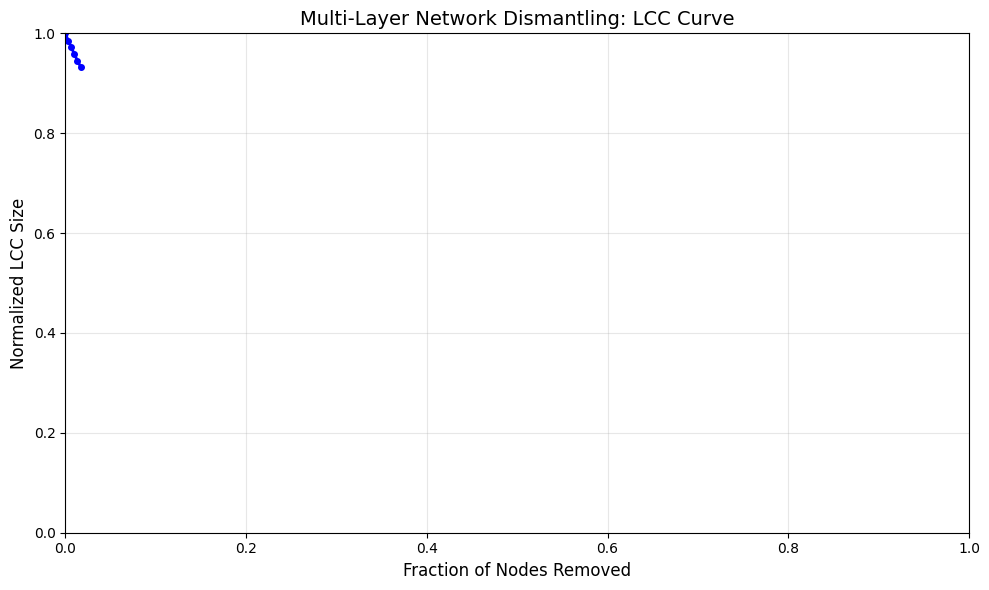


Key Statistics:
Original LCC size: 29652 (100.00%)
Final LCC size: 27671 (93.32%)
Nodes removed to reach 50% LCC: 1.69%


In [20]:
# Plot the LCC curve
normalized_lcc = [lcc / original_size for lcc in lcc_sizes]
removed_fraction = [r / original_size for r in removed_nodes]

plt.figure(figsize=(10, 6))
plt.plot(removed_fraction, normalized_lcc, 'b-', linewidth=2, marker='o', markersize=4)
plt.xlabel('Fraction of Nodes Removed', fontsize=12)
plt.ylabel('Normalized LCC Size', fontsize=12)
plt.title('Multi-Layer Network Dismantling: LCC Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"\nKey Statistics:")
print(f"Original LCC size: {lcc_sizes[0]} ({normalized_lcc[0]:.2%})")
print(f"Final LCC size: {lcc_sizes[-1]} ({normalized_lcc[-1]:.2%})")
print(f"Nodes removed to reach 50% LCC: {removed_fraction[np.argmin(np.abs(np.array(normalized_lcc) - 0.5))]:.2%}")